First, Input all of the possible packages that I need for the project

In [5]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
import seaborn as sns 
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

Then I load the dataset and use varibles like df.head, df.columns to get more info about the dataset.

More about the dataset: The dataset is from FEVER (Fact Extraction and VERification) which is an academic research initiative and workshop series focused on automated fact‑checking and verification using artificial intelligence and natural language processing (NLP). Its a long‑running research program/ community centered on helping AI systems: Automatically extract factual claims, Retrieve evidence from large text collections (like the web or Wikipedia), and Verify whether claims are supported, refuted, or unverifiable.

In [6]:
df = pd.read_csv(r"C:\Users\MRyan\OneDrive\Documents\Fabricated Facts about LLM.csv")

In [3]:
df.head()

,ID,Verifiable,Label,Claim,Evidence,Evidence 1,Evidence 2,Evidence 3,Evidence 4,Evidence 5,Evidence 6,Evidence 8
0,75397,"VERIFIABLE,","SUPPORTS,",Nikolaj Coster-Waldau worked with the Fox Broa...,"[[[92206,","104971,","Nikolaj_Coster-Waldau,","7],","[92206,","104971,","Fox_Broadcasting_Company,",0]]]}
1,150448,"VERIFIABLE,","SUPPORTS,","Roman Atwood is a content creator.,","[[[174271,","187498,","Roman_Atwood,","1]],","[[174271,","187499,","Roman_Atwood,",3]]]}
2,214861,"VERIFIABLE,","SUPPORTS,","History of art includes architecture, dance, s...","[[[255136,","254645,","History_of_art,",2]]]},NaN,NaN,NaN,NaN
3,156709,"VERIFIABLE,","REFUTES,","Adrienne Bailon is an accountant.,","[[[180804,","193183,","Adrienne_Bailon,",0]]]},NaN,NaN,NaN,NaN
4,83235,"NOT VERIFIABLE,","NOT ENOUGH INFO,","System of a Down briefly disbanded in limbo.,","[[[100277,","null,","null,",null]]]},NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145449 entries, 0 to 145448
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   ID          145449 non-null  int64 
 1   Verifiable  145449 non-null  object
 2   Label       145449 non-null  object
 3   Claim       145449 non-null  object
 4   Evidence    145448 non-null  object
 5   Evidence 1  145449 non-null  object
 6   Evidence 2  145449 non-null  object
 7   Evidence 3  145449 non-null  object
 8   Evidence 4  47592 non-null   object
 9   Evidence 5  47412 non-null   object
 10  Evidence 6  47293 non-null   object
 11  Evidence 8  47191 non-null   object
dtypes: int64(1), object(11)
memory usage: 13.3+ MB


In [5]:
df.columns

Index(['ID', 'Verifiable', 'Label', 'Claim', 'Evidence', 'Evidence 1',
       'Evidence 2', 'Evidence 3', 'Evidence 4', 'Evidence 5', 'Evidence 6',
       'Evidence 8'],
      dtype='object')

Even though I don't really have a lot categorical variables, I want to see how many bins each of them has or if even not.

In [6]:
for col in df.columns:
    print(f"{col}:\n {df[col].value_counts()}\n")

ID:
 ID
152180    1
75397     1
150448    1
214861    1
156709    1
         ..
188923    1
76253     1
40190     1
226034    1
6744      1
Name: count, Length: 145449, dtype: int64

Verifiable:
 Verifiable
VERIFIABLE,        109810
NOT VERIFIABLE,     35639
Name: count, dtype: int64

Label:
 Label
SUPPORTS,           80035
NOT ENOUGH INFO,    35639
REFUTES,            29775
Name: count, dtype: int64

Claim:
 Claim
International Relations only includes the entertainment industry.,    33
International Relations includes many subject matters.,               28
International Relations includes animals.,                            24
International Relations includes the U.N.,                            19
Oliver Reed was in a movie.,                                          16
                                                                      ..
There is a movie called The Hunger Games.,                             1
Ryan Gosling has been to a country in Africa.,                        

As you can see, I had a lot of columns that said evidence so I decided to combine all of them together because some didn't have a lot of information and some of them did.

In [7]:
df['Combined_Evidence'] = df[['Evidence', 'Evidence 1', 'Evidence 2', 'Evidence 3', 'Evidence 4', 'Evidence 5', 'Evidence 6', 'Evidence 8']].apply(lambda row: [val for val in row if pd.notna(val)], axis=1)

After that I combined all of the information into the one column, I drop the rest of the colunms that said evidence except the one I created. Also, I drop ID because I felt it wasn't nessacary.

In [12]:
df = df.drop(columns=['Evidence', 'Evidence 1', 'Evidence 2', 'Evidence 3', 'Evidence 4', 'Evidence 5', 'Evidence 6', 'Evidence 8'])

KeyError: "['Evidence', 'Evidence 1', 'Evidence 2', 'Evidence 3', 'Evidence 4', 'Evidence 5', 'Evidence 6', 'Evidence 8'] not found in axis"

In [13]:
df = df.drop(columns=['ID'])

Check the info after all dropping the columns

In [14]:
df

,Verifiable,Label,Claim,Combined_Evidence
0,"VERIFIABLE,","SUPPORTS,",Nikolaj Coster-Waldau worked with the Fox Broa...,"[[[[92206,, 104971,, Nikolaj_Coster-Waldau,, 7..."
1,"VERIFIABLE,","SUPPORTS,","Roman Atwood is a content creator.,","[[[[174271,, 187498,, Roman_Atwood,, 1]],, [[1..."
2,"VERIFIABLE,","SUPPORTS,","History of art includes architecture, dance, s...","[[[[255136,, 254645,, History_of_art,, 2]]]}]"
3,"VERIFIABLE,","REFUTES,","Adrienne Bailon is an accountant.,","[[[[180804,, 193183,, Adrienne_Bailon,, 0]]]}]"
4,"NOT VERIFIABLE,","NOT ENOUGH INFO,","System of a Down briefly disbanded in limbo.,","[[[[100277,, null,, null,, null]]]}]"
...,...,...,...,...
145444,"VERIFIABLE,","REFUTES,",Led Zeppelin released an eponymous debut album...,"[[[[91851,, 104659,, Led_Zeppelin,, 6],, [9185..."
145445,"VERIFIABLE,","SUPPORTS,","Taal was romantic.,","[[[[292586,, 285327,, Taal_-LRB-film-RRB-,, 0]..."
145446,"VERIFIABLE,","SUPPORTS,","Her stars American actress Rooney Mara.,","[[[[28520,, 34848,, Her_-LRB-film-RRB-,, 3],, ..."
145447,"VERIFIABLE,","SUPPORTS,","J. R. R. Tolkien created Gimli.,","[[[[28359,, 34669,, Gimli_-LRB-Middle-earth-RR..."


I specifically chose a pie chart for the visual because I was comparing how much the info is verifiable and does it support or not.

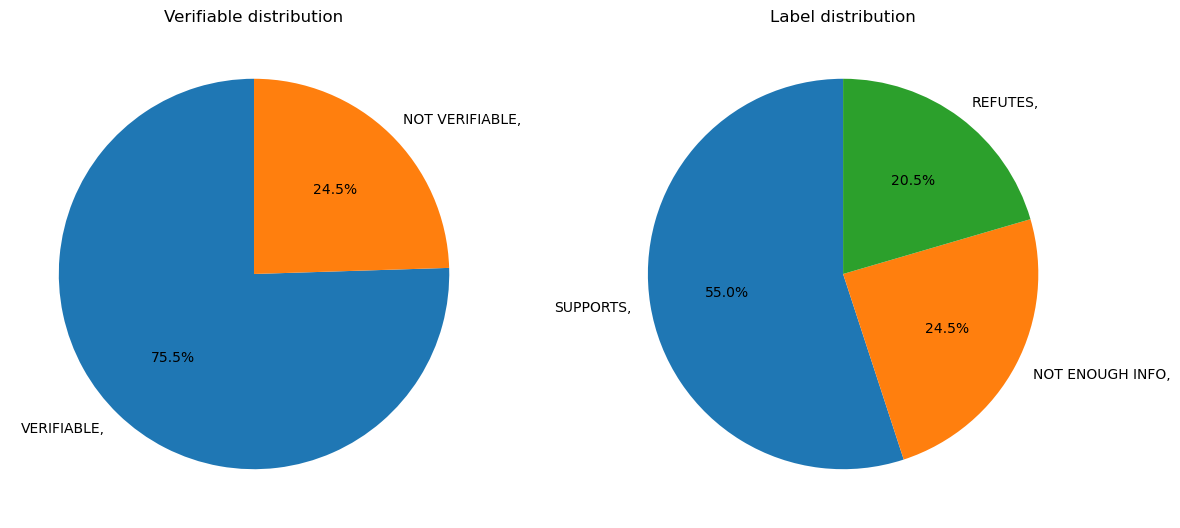

In [19]:
counts_verifiable = df['Verifiable'].value_counts()
counts_label = df['Label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].pie(
    counts_verifiable,
    labels=counts_verifiable.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Verifiable distribution')

axes[1].pie(
    counts_label,
    labels=counts_label.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Label distribution')

plt.tight_layout()
plt.show()

I chose the train_test_split because since the data is so huge and I wanted to see what data is really accuarate.

In [2]:
from sklearn.model_selection import train_test_split

In [7]:
X = df['Verifiable']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)

In [8]:
from sklearn import tree

In [9]:
clf = tree.DecisionTreeClassifier()

In [12]:
X_enc = df['Verifiable'].map({'VERIFIABLE,': 1, 'NOT VERIFIABLE,': 0}).to_frame()
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(X_enc, y, test_size=0.2, random_state=42, stratify=y)

tree_clf = tree.DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

print("Train accuracy:", tree_clf.score(X_train, y_train))
print("Test accuracy:", tree_clf.score(X_test, y_test))

Train accuracy: 0.7952887185348791
Test accuracy: 0.7952904778274321


In [13]:
clf.score(X_test,y_test)

0.7952904778274321

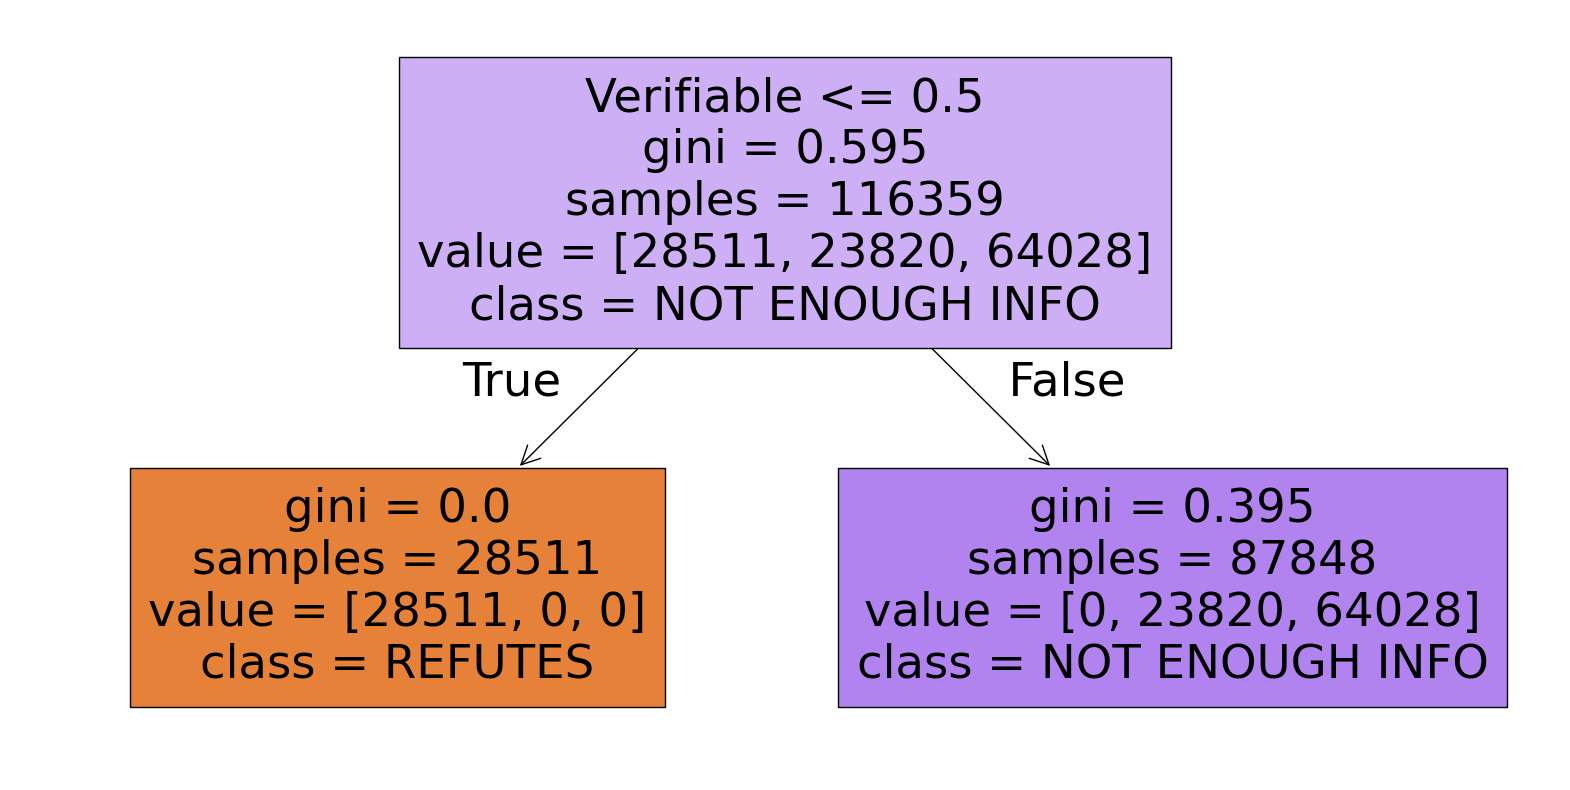

In [15]:
plt.figure(figsize=(20,10))
tree.plot_tree(tree_clf, filled=True, feature_names=['Verifiable'], class_names=['REFUTES', 'SUPPORTS', 'NOT ENOUGH INFO'])
plt.show()